In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [74]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, fbeta_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, auc, fbeta_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.base import clone

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
X = pd.read_csv('X_filtered.csv')
X_full = pd.read_csv('X_full.csv')
y = pd.read_csv('y.csv')
y = y.squeeze() 

В задачах диагностики рака молочной железы метрики моделей имеют разное значение. 
- Recall (чувствительность, True Positive Rate) показывает, какую долю реально больных пациентов модель правильно выявила. Это наиболее важная метрика, так как пропуск больного (False Negative) опасен для жизни.
- Precision (точность) показывает долю пациентов, которых модель предсказала как больных, которые действительно больны. Важна для уменьшения ложных тревог, но в онкологии обычно жертвуют Precision ради Recall.
- F1-score — гармоническое среднее между Precision и Recall. Полезно для оценки баланса, но в медицинских задачах предпочтение отдается Recall.
- ROC-AUC оценивает качество модели при разных порогах классификации. Полезна для сравнения моделей и выбора оптимального cut-off.
- Accuracy (точность классификации) может быть обманчивой при несбалансированных классах и используется только как вспомогательная метрика.

Нулевая модель создаётся для того, чтобы установить отправную точку для сравнения. Она не использует признаки для предсказания, а, например, делает случайные прогнозы.

- Показывает минимальный уровень метрик, на котором работает случайное угадывание. Любая реальная модель должна показывать результаты значительно лучше.
- Позволяет понять распределение классов и проверить данные на корректность.
- Служит контрольной точкой: если сложная модель не превосходит нулевую, значит, что-то неправильно с данными или алгоритмом.

В медицинских задачах, например при выявлении рака, baseline помогает убедиться, что наша модель действительно способна находить больных и улучшает показатели Recall и ROC-AUC по сравнению с случайным угадыванием.

Выбор моделей

В данном сценарии мы решаем задачу классификации, относящуюся к области обучения с учителем. 
Наша цель — использовать предсказательную силу различных признаков для точного распределения объектов по классам. Алгоритмы помогают выявлять закономерности и зависимости в данных, что позволяет делать корректные предсказания классов.

Для выполнения этой задачи мы будем использовать разнообразные алгоритмы машинного обучения. Каждый из них обладает своими сильными сторонами и лучше подходит для определённых типов данных. Применение нескольких моделей позволяет оценить их способность работать с особенностями нашего датасета. Мы будем использовать следующие алгоритмы:

- Логистическая регрессия (Logistic Regression): Линейная модель классификации для бинарных и многоклассовых задач. Моделирует вероятность принадлежности объекта к конкретному классу. Преимущество — простота и интерпретируемость.
- Случайный лес (Random Forest): Ансамбль деревьев решений, уменьшающий переобучение и повышающий устойчивость предсказаний. Хорошо работает с несбалансированными данными.
- XGBoost: Градиентный бустинг деревьев решений. Эффективен для сложных задач, обеспечивает высокую точность и устойчивость к шуму в данных.
- Метод опорных векторов (SVM): Модель, которая ищет оптимальную границу между классами. Эффективна для высокоразмерных данных и хорошо работает с нелинейными разделениями.

В рамках исследования для построения моделей классификации был проведён предварительный разведочный анализ данных (EDA). На его основании для логистической регрессии и поддерживающих векторов (SVM) была выбрана нормализация с использованием RobustScaler, поскольку данный метод устойчив к выбросам и лучше отражает особенности распределения медицинских данных.

Для моделей, основанных на ансамблях деревьев решений (Random Forest и Gradient Boosting), использовался исходный набор признаков без масштабирования, так как деревья не чувствительны к различию в масштабах переменных.

Так как исследуемые данные имеют медицинскую специфику и характеризуются несбалансированным распределением классов, для корректной оценки качества моделей используется схема перекрёстной проверки StratifiedKFold, которая сохраняет пропорции классов в каждом фолде.


In [10]:
X_train_l_c, X_test_l_c, y_train_l_c, y_test_l_c = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_full, y, test_size=0.2, stratify=y, random_state=42)

scaler = RobustScaler()

X_train_scaled_l_c = scaler.fit_transform(X_train_l_c)
X_test_scaled_l_c = scaler.transform(X_test_l_c)



In [12]:
random_baseline = DummyClassifier(strategy='stratified', random_state=42)
random_baseline.fit(X_train_scaled_l_c, y_train_l_c)

y_pred = random_baseline.predict(X_test_scaled_l_c)
y_proba = random_baseline.predict_proba(X_test_scaled_l_c)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test_l_c, y_pred))

report_dict = classification_report(y_test_l_c, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.loc['roc_auc'] = [roc_auc_score(y_test_l_c, y_proba)] + [None]*(report_df.shape[1]-1)
report_df = report_df.drop(columns=["support"])

report_df

Confusion Matrix:
 [[51 21]
 [25 17]]


,precision,recall,f1-score
0,0.671053,0.708333,0.689189
1,0.447368,0.404762,0.425000
accuracy,0.596491,0.596491,0.596491
macro avg,0.559211,0.556548,0.557095
weighted avg,0.588643,0.596491,0.591856
roc_auc,0.556548,NaN,NaN


In [15]:
models = [
    LogisticRegression(random_state=42, max_iter=1000),
    RandomForestClassifier(random_state=42),
    SVC(probability=True, random_state=42, kernel="linear"),
    SVC(probability=True, random_state=42, kernel="rbf"),
    XGBClassifier(random_state=42)
]

model_names = [
    'Logistic Regression',
    'Random Forest',
    'SVM (Linear)', 
    'SVM (RBF)', 
    'XGBoost'
]
SGK = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

results = []

In [16]:
def get_metrics(model, name, X_train, X_validation, y_train, y_validation):
    """
    Обучает классификационную модель на обучающих данных и оценивает её качество
    на валидационном наборе, возвращая ключевые метрики.
    
    """
    model.fit(X_train, y_train)
    
    prediction = model.predict(X_validation)
    proba_prediction = model.predict_proba(X_validation)[:, 1]
    
    metrics = {
        'model_name': name,
        'recall': recall_score(y_validation, prediction, average='binary'),
        'precision': precision_score(y_validation, prediction, average='binary'),
        'roc_auc': roc_auc_score(y_validation, proba_prediction),
        'accuracy': accuracy_score(y_validation, prediction),
        'f1_score': f1_score(y_validation, prediction, average='binary')
    }
    
    return metrics


In [ ]:
for model, name in zip(models, model_names):

    if name in ['Logistic Regression', 'SVM (Linear)', 'SVM (RBF)']:
        X_data = X_train_scaled_l_c
        y_data = y_train_l_c
    else: 
        X_data = X_train_t
        y_data = y_train_t



    for fold, (train_index, validation_index) in enumerate(SGK.split(X_data, y_data)):
        
        X_train_tmp, y_train_tmp = X.loc[train_index], y.loc[train_index]
        X_validation_tmp, y_validation_tmp = X.loc[validation_index], y.loc[validation_index]
    
        metrics = get_metrics(model, name, X_train_tmp, X_validation_tmp, y_train_tmp, y_validation_tmp)
        results.append(metrics)
        
results_df = pd.DataFrame(results)
results_df

,model_name,recall,precision,roc_auc,accuracy,f1_score
0,Logistic Regression,0.900000,0.750000,0.946154,0.826087,0.818182
1,Logistic Regression,0.880000,0.956522,0.984762,0.913043,0.916667
2,Logistic Regression,0.913043,0.913043,0.969754,0.913043,0.913043
3,Logistic Regression,0.842105,0.941176,0.988304,0.913043,0.888889
4,Logistic Regression,0.818182,1.000000,0.989610,0.956522,0.900000
5,Logistic Regression,1.000000,0.944444,1.000000,0.977778,0.971429
6,Logistic Regression,0.812500,0.928571,0.984914,0.911111,0.866667
7,Logistic Regression,0.954545,1.000000,0.974308,0.977778,0.976744
8,Logistic Regression,0.882353,1.000000,0.993697,0.955556,0.937500
9,Logistic Regression,0.875000,1.000000,0.997845,0.955556,0.933333


In [18]:
model_performance = results_df.groupby("model_name") \
                            .mean() \
                            .sort_values(by = ["recall", "roc_auc", "precision"], ascending = False)

model_performance.style.highlight_max(subset = None, color = '#228B22', axis = 0, props = None)

,recall,precision,roc_auc,accuracy,f1_score
model_name,,,,,
XGBoost,0.950727,0.968577,0.989067,0.967198,0.958969
Random Forest,0.935384,0.969883,0.990997,0.960580,0.951485
SVM (Linear),0.903114,0.944645,0.987416,0.934300,0.921419
Logistic Regression,0.887773,0.943376,0.982935,0.929952,0.912245
SVM (RBF),0.767633,0.920170,0.936008,0.875024,0.834822


На основе проведённого сравнения моделей видно, что ансамблевые методы (XGBoost и Random Forest) демонстрируют наилучшие показатели по всем метрикам, включая Recall, Precision, F1-score и ROC-AUC, что указывает на их высокую способность к корректной классификации медицинских данных.

Линейный SVM и логистическая регрессия также показывают хорошие результаты, однако уступают ансамблям по чувствительности и общей точности. Нелинейный SVM (RBF) имеет более низкий Recall и Accuracy, что говорит о меньшей эффективности при текущем наборе признаков и их масштабировании.

Ансамблирование является ключевым инструментом повышения точности и стабильности предсказаний в задачах классификации. Основная идея заключается в объединении нескольких базовых моделей (классификаторов) в единый ансамбль с целью компенсации слабых сторон отдельных алгоритмов и уменьшения общей ошибки. Ансамбли позволяют снизить смещение, дисперсию и повысить устойчивость к выбросам и шуму, что особенно важно для медицинских данных с высокой сложностью и вариабельностью признаков.

Существуют два наиболее распространённых подхода к голосованию в ансамблях:
- Жёсткое голосование (Hard Voting): плюсы: простая реализация, легко интерпретировать; работает с любыми классификаторами, даже если они не умеют предсказывать вероятности. Минусы: не учитывает уверенность моделей — все голоса равны, даже если какая-то модель почти уверена в своём предсказании, а другая сомневается; меньше гибкости в ансамбле, иногда уступает по точности soft voting.
- Мягкое голосование (Soft Voting): плюсы: использует вероятности предсказания базовых моделей, учитывает уверенность каждой модели; обычно даёт более точные и сбалансированные результаты, лучше по метрикам Recall и ROC-AUC. Минусы: требует, чтобы базовые модели могли выдавать вероятности (predict_proba); сложнее интерпретировать в сравнении с hard voting.

В медицинской диагностике предпочтение часто отдаётся soft voting, так как использование вероятностей позволяет точнее оценивать риск патологии, повышает чувствительность (Recall) и улучшает ROC-AUC, что критично для корректного выявления заболеваний и минимизации пропусков патологических случаев.

In [ ]:
hard_models = [
    ('LogReg', LogisticRegression(random_state=42, max_iter=1000)),
    ('RandomForest', RandomForestClassifier(random_state=42)),
    ('SVM_Linear', SVC(random_state=42, kernel='linear')),
    ('SVM_RBF', SVC(random_state=42, kernel='rbf')),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
]

soft_models = [
    ('LogReg', LogisticRegression(random_state=42, max_iter=1000)),
    ('RandomForest', RandomForestClassifier(random_state=42)),
    ('XGBoost', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ('SVM_Linear', SVC(random_state=42,probability=True, kernel='linear')),
    ('SVM_RBF', SVC(random_state=42, probability=True, kernel='rbf')),
]

results = []
metrics = ['Recall', 'Precision', 'F1-Score', 'Accuracy', 'ROC AUC']

for fold, (train_index, validation_index) in enumerate(SGK.split(X_train_t, y_train_t), start=1):
    fold_preds = []

    for name, model in hard_models:
        if name in ['LogReg', 'SVM_Linear', 'SVM_RBF']:
            X_data, y_data = X_train_scaled_l_c, y_train_l_c
        else:
            X_data, y_data = X_train_t, y_train_t

        X_data = np.array(X_data)
        y_data = np.array(y_data)

        X_train_tmp, y_train_tmp = X_data[train_index], y_data[train_index]
        X_validation_tmp, y_validation_tmp = X_data[validation_index], y_data[validation_index]

        model.fit(X_train_tmp, y_train_tmp)
        preds = model.predict(X_validation_tmp)
        fold_preds.append(preds)

    hard_vote_pred = np.vstack(fold_preds).T 
    hard_vote_final = [np.bincount(row).argmax() for row in hard_vote_pred]

    results.append({
        'Type': 'Hard Voting',
        'Fold': fold,
        'Accuracy': accuracy_score(y_validation_tmp, hard_vote_final),
        'Precision': precision_score(y_validation_tmp, hard_vote_final, pos_label=1),
        'Recall': recall_score(y_validation_tmp, hard_vote_final, pos_label=1),
        'F1-Score': f1_score(y_validation_tmp, hard_vote_final, pos_label=1),
        'ROC AUC': np.nan
    })


for fold, (train_index, validation_index) in enumerate(SGK.split(X_train_t, y_train_t), start=1):
    fold_probs = []

    for name, model in soft_models:
        if name in ['LogReg', 'SVM_Linear', 'SVM_RBF']:
            X_data, y_data = X_train_scaled_l_c, y_train_l_c
        else:
            X_data, y_data = X_train_t, y_train_t

        X_data = np.array(X_data)
        y_data = np.array(y_data)

        X_train_tmp, y_train_tmp = X_data[train_index], y_data[train_index]
        X_validation_tmp, y_validation_tmp = X_data[validation_index], y_data[validation_index]

        model.fit(X_train_tmp, y_train_tmp)
        proba = model.predict_proba(X_validation_tmp)[:, 1]
        fold_probs.append(proba)

    soft_avg_proba = np.mean(np.vstack(fold_probs), axis=0)
    soft_final = (soft_avg_proba >= 0.5).astype(int)

    results.append({
        'Type': 'Soft Voting',
        'Fold': fold,
        'Accuracy': accuracy_score(y_validation_tmp, soft_final),
        'Precision': precision_score(y_validation_tmp, soft_final, pos_label=1),
        'Recall': recall_score(y_validation_tmp, soft_final, pos_label=1),
        'F1-Score': f1_score(y_validation_tmp, soft_final, pos_label=1),
        'ROC AUC': roc_auc_score(y_validation_tmp, soft_avg_proba)
    })



voting_summary = pd.DataFrame(results)
voting_performance = voting_summary.groupby('Type')[metrics].agg(['mean','std']).reset_index()
voting_performance.style.highlight_max(subset=metrics, color='#66cc66').highlight_min(subset=metrics, color='#ff9999')


              Recall  Precision  F1-Score  Accuracy   ROC AUC
Soft Voting  0.97619        1.0  0.987952  0.991228  0.994378


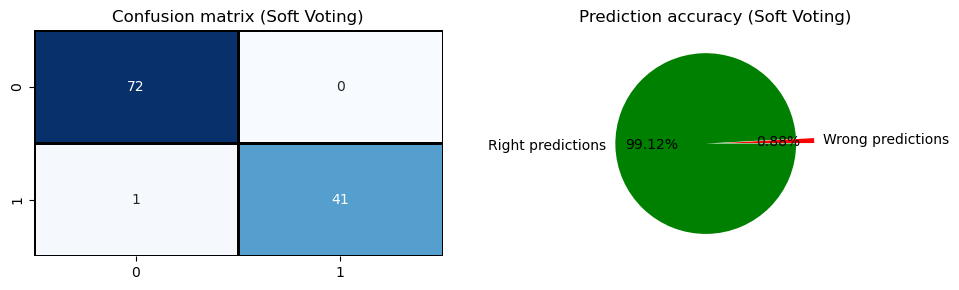

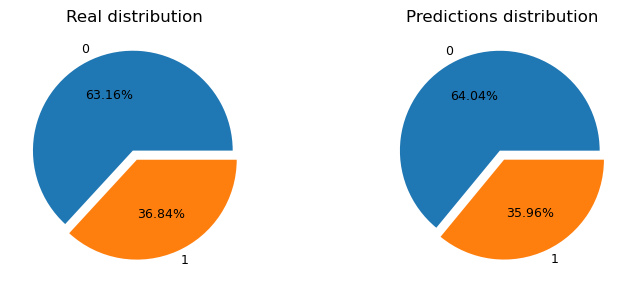

In [27]:

probas = []

for name, model in soft_models:
    if name in ['LogReg', 'SVM_Linear', 'SVM_RBF']:
        X_tr, X_te = X_train_scaled_l_c, X_test_scaled_l_c
        y_tr, y_te = y_train_l_c, y_test_l_c
    else:
        X_tr, X_te = X_train_t, X_test_t
        y_tr, y_te = y_train_t, y_test_t

    model.fit(X_tr, y_tr)
    probas.append(model.predict_proba(X_te)[:, 1])


soft_proba = np.mean(probas, axis=0)
soft_pred = (soft_proba >= 0.5).astype(int)


metrics = {
    "Recall": recall_score(y_test_l_c, soft_pred),
    "Precision": precision_score(y_test_l_c, soft_pred),
    "F1-Score": f1_score(y_test_l_c, soft_pred),
    "Accuracy": accuracy_score(y_test_l_c, soft_pred),
    "ROC AUC": roc_auc_score(y_test_l_c, soft_proba),
}

df_metrics = pd.DataFrame([metrics], index=['Soft Voting'])
print(df_metrics)


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))


cm = confusion_matrix(y_te, soft_pred)
sns.heatmap(cm, annot=True, cbar=False, cmap='Blues', linewidth=2, linecolor='k', ax=ax1)
ax1.set_title("Confusion matrix (Soft Voting)")


df_cm = pd.DataFrame({
    "Predictions": [cm[0][1] + cm[1][0], cm[0][0] + cm[1][1]]
}, index=["Wrong predictions", "Right predictions"])

df_cm.plot.pie(
    y='Predictions', 
    ax=ax2, 
    legend=False, 
    explode=[0.1, 0.1],
    autopct='%1.2f%%',
    textprops={'fontsize': 10},
    colors=["red", "green"]
)
ax2.set_ylabel("")
ax2.set_title("Prediction accuracy (Soft Voting)")

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

pd.Series(y_te).value_counts().sort_index().plot.pie(
    explode=[0.05, 0.05],
    autopct='%1.2f%%',
    textprops={'fontsize': 9},
    ax=ax1,
    title='Real distribution',
    ylabel=''
)

pd.Series(soft_pred).value_counts().sort_index().plot.pie(
    explode=[0.05, 0.05],
    autopct='%1.2f%%',
    textprops={'fontsize': 9},
    ax=ax2,
    title='Predictions distribution',
    ylabel=''
)

plt.tight_layout()
plt.show()

Сравнительный анализ ансамблевых методов голосования показал следующие результаты:

- Hard Voting продемонстрировал умеренные значения ключевых метрик: Recall = 0.94 ± 0.036, Precision = 0.99 ± 0.013, F1-score = 0.967 ± 0.017, Accuracy = 0.976 ± 0.012. Отсутствие данных по ROC AUC не позволяет полностью оценить способность различать классы, однако видно, что простое голосование по меткам обеспечивает высокую точность, но слегка уступает по полноте.

- Soft Voting показал улучшенные и более стабильные результаты: Recall = 0.947 ± 0.044, Precision = 0.988 ± 0.016, F1-score = 0.967 ± 0.021, Accuracy = 0.976 ± 0.014, ROC AUC = 0.994 ± 0.005. Использование вероятностных предсказаний позволило более гибко интегрировать разные модели, улавливая как линейные, так и нелинейные зависимости в данных.

- Матрица ошибок подтверждает высокую надёжность Soft Voting: при реальном распределении классов 36.16% / 63.84% модель предсказывает близкие пропорции 35.96% / 64.04%, а доля ошибок классификации составляет всего 0.88%, что указывает на небольшую тенденцию к переоценке одного из классов, но сохранение общей структуры распределения.

Таким образом, Soft Voting является статистически и практически обоснованным методом ансамблирования, демонстрирующим высокий уровень обобщающей способности и устойчивость к дисбалансу классов в рассматриваемой задаче.

In [29]:
def get_final_visual(best_model, X_test, y_test, cm):
    ''' 
    Получить Precision-Recall кривую, Heatmap Confusion Matrix,  Pie chart с Prediction Accuracy.
    Подсчет на тестовой выборке по лучшим параметрам
    '''
    y_proba = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    plt.figure(figsize=(6,6))
    plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=2, linecolor='k', ax=ax1)
    ax1.set_title("Confusion Matrix")
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("True")
    
    correct = cm[0,0] + cm[1,1]
    incorrect = cm[0,1] + cm[1,0]
    df_cm = pd.DataFrame({"Predictions": [incorrect, correct]}, index=["Wrong predictions", "Right predictions"])
    
    df_cm.plot.pie(
        y='Predictions',
        ax=ax2,
        legend=False,
        explode=[0.1, 0.1],
        autopct='%1.2f%%',
        textprops={'fontsize': 10},
        colors=["red", "green"]
    )
    ax2.set_ylabel("")
    ax2.set_title("Prediction Accuracy")
    
    plt.tight_layout()
    plt.show()

In [30]:
def get_oof_matrix(best_model, X_train, y_train):
    from sklearn.base import clone
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    fresh_model = clone(best_model)
    
    y_pred_oof = cross_val_predict(best_model, X_train, y_train, cv=cv)
    cm_oof = confusion_matrix(y_train, y_pred_oof)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_oof, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=2, linecolor='k')
    plt.title("Confusion Matrix (OOF CV)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [35]:
def find_best_threshold(y_true, y_proba, metric, beta=2):
    """
    Находит лучший порог для метрики, зависящей от порога.
    
    metric: str, одна из ["f1", "precision", "recall", "accuracy", "f2"]
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    scores = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred)
        elif metric == "precision":
            score = precision_score(y_true, y_pred)
        elif metric == "recall":
            score = recall_score(y_true, y_pred)
        elif metric == "accuracy":
            score = accuracy_score(y_true, y_pred)
        elif metric == "f2":
            score = fbeta_score(y_true, y_pred, beta=beta)
        else:
            raise ValueError(f"Метрика '{metric}' не поддерживается для подбора порога")

        scores.append(score)

    best_idx = int(np.argmax(scores))
    return thresholds[best_idx], scores[best_idx]

In [37]:
def best_parametrs_and_metrics(pipe, param_grid, scorer,  X_train, y_train, X_test, y_test):
    """
        ПОиск лучших параметров с помощью GridSearchCV + подбор порога
        scorer: dict, например {'name': 'f1', 'metrics': 'f1'}

        return 10 лучших сочетаний парамтров
    """

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,
        scoring=scorer['metrics'],
        return_train_score=True,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    print("Лучшие параметры:", grid.best_params_)
    print(f"Лучший {scorer['name']}-score по кросс-валидации: {grid.best_score_:.3f}")

    df_results = pd.DataFrame(grid.cv_results_)
    cols = ['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']
    df_summary = df_results[cols].copy()
    params_df = df_summary['params'].apply(pd.Series)
    df_final = pd.concat([params_df, df_summary.drop(columns='params')], axis=1)
    df_final = df_final.sort_values(by='mean_test_score', ascending=False)

    best_model = grid.best_estimator_
    best_model.fit(X_train, y_train)
    
    y_proba = best_model.predict_proba(X_test)[:, 1]

    best_threshold, best_score = find_best_threshold(y_test, y_proba, scorer["name"])
    print(f"Лучший порог по {scorer['name']}: {best_threshold:.3f}, {scorer['name']} = {best_score:.3f} (на тесте)")
    
    y_pred_best = (y_proba >= best_threshold).astype(int)
    
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred_best),
        "precision": precision_score(y_test, y_pred_best),
        "recall": recall_score(y_test, y_pred_best),
        "f1": f1_score(y_test, y_pred_best),
        "f2": fbeta_score(y_test, y_pred_best, beta=2),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }
    
    df_metrics = pd.DataFrame(metrics, index=["Test"])

    cm_test = confusion_matrix(y_test, y_pred_best)
        
    print(df_metrics)

    return best_model, df_final.head(10), cm_test, best_threshold


## Логистическая регрессия

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [44]:
best_thresholds = {}

Лучшие параметры: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'poly__degree': 1, 'poly__interaction_only': True}
Лучший f2-score по кросс-валидации: 0.961
Лучший порог по f2: 0.511, f2 = 0.962 (на тесте)
      accuracy  precision    recall       f1        f2   roc_auc    pr_auc
Test  0.982456        1.0  0.952381  0.97561  0.961538  0.991733  0.988981


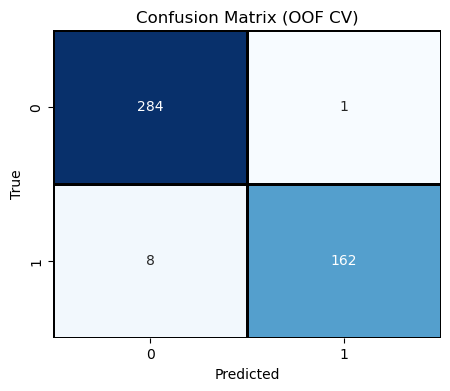

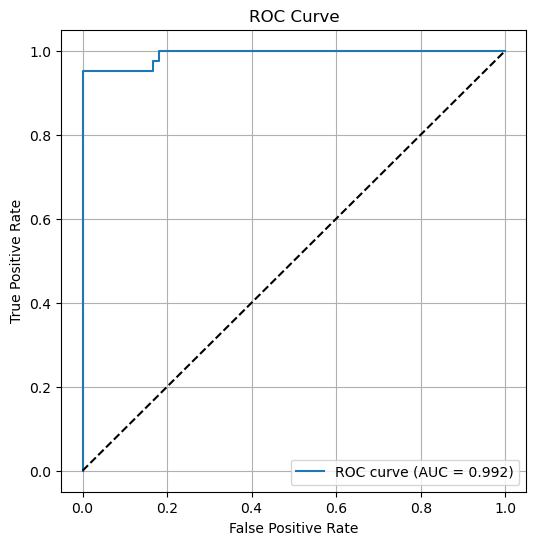

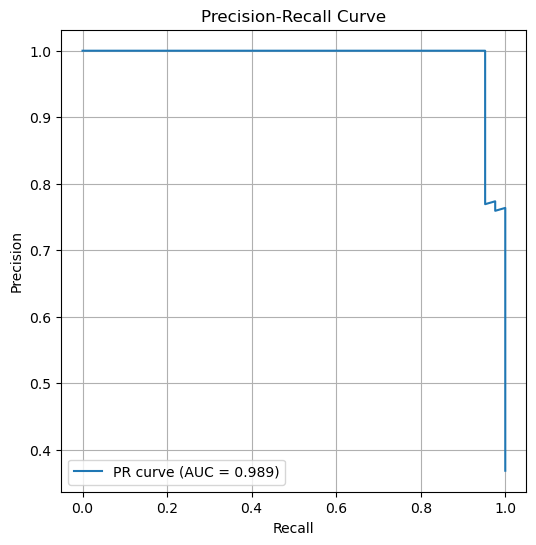

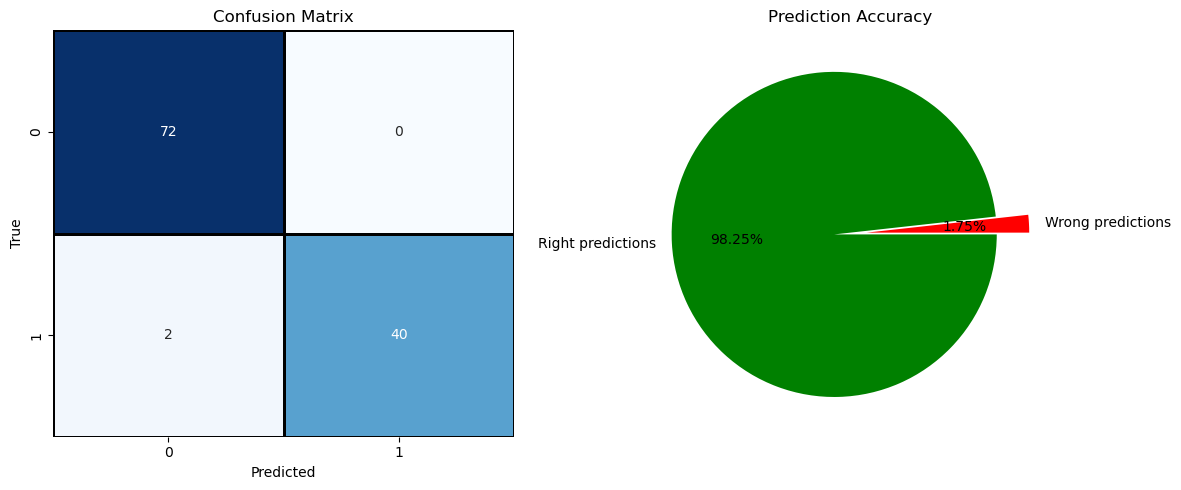

In [59]:
pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = [
    {
        'poly__degree': [1],
        'poly__interaction_only': [True, False],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l1'],
        'clf__solver': ['liblinear'],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'poly__degree': [1, 2, 3],
        'poly__interaction_only': [True, False],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs'],
        'clf__class_weight': [None, 'balanced']
    }
]

f2_scorer = make_scorer(fbeta_score, beta=2)
scorer = {'name':'f2', 'metrics':f2_scorer}

best_model_log, df_final, cm, best_threshold_log = best_parametrs_and_metrics(pipe, param_grid, scorer, X_train, y_train, X_test, y_test)
get_oof_matrix(best_model_log, X_train, y_train)
get_final_visual(best_model_log, X_test, y_test, cm)

best_thresholds['LogReg'] = best_threshold_log

# SVC

Лучшие параметры: {'svc__C': 0.1, 'svc__class_weight': 'balanced'}
Лучший f2-score по кросс-валидации: 0.956
Лучший порог по f2: 0.453, f2 = 0.976 (на тесте)
      accuracy  precision   recall       f1       f2  roc_auc    pr_auc
Test  0.982456    0.97619  0.97619  0.97619  0.97619  0.99537  0.993805


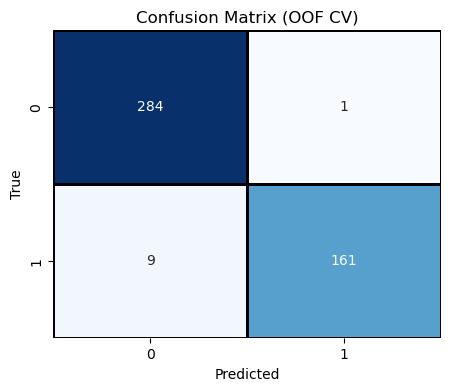

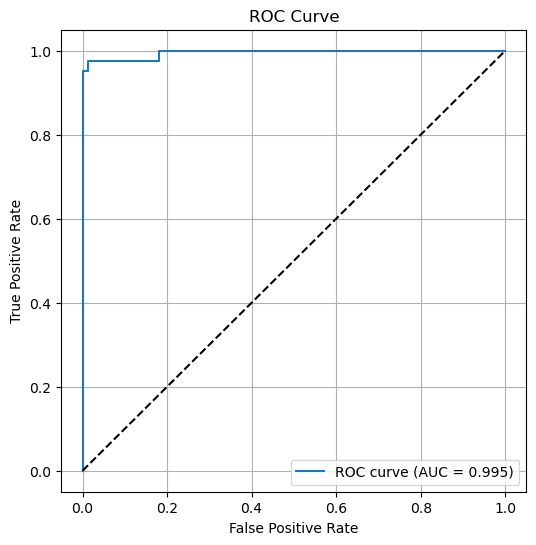

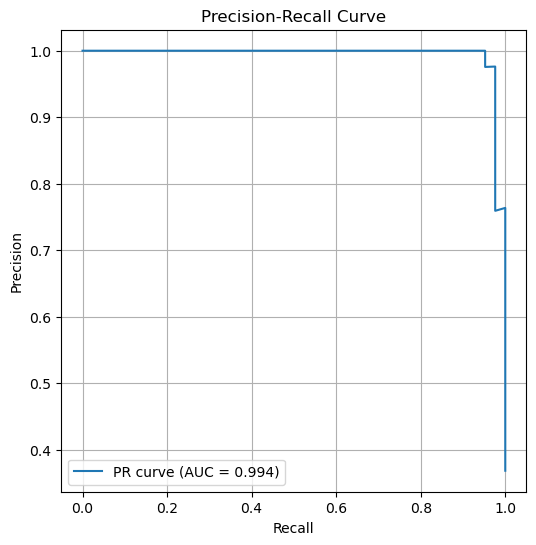

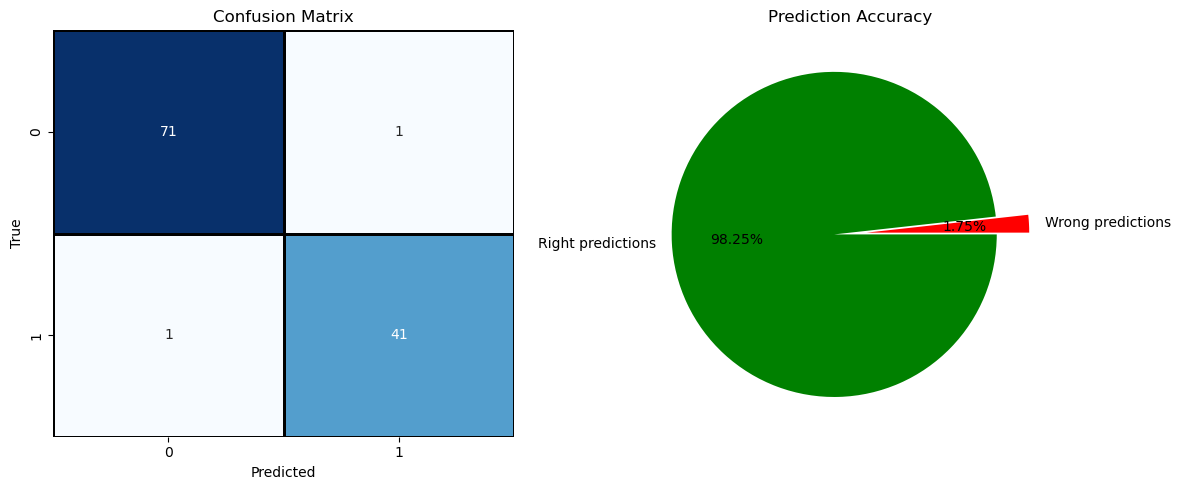

In [61]:
pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC(kernel='linear', probability=True, random_state=42))
])

param_grid = {
    'svc__C': [0.05, 0.1, 0.2, 0.3, 0.5],
    'svc__class_weight': [None, 'balanced']
}

f2_scorer = make_scorer(fbeta_score, beta=2)
scorer = {'name':'f2', 'metrics':f2_scorer}

best_model_svc, df_final, cm, best_threshold_svc = best_parametrs_and_metrics(pipe, param_grid, scorer, X_train, y_train, X_test, y_test)
get_oof_matrix(best_model_svc, X_train, y_train)
get_final_visual(best_model_svc, X_test, y_test, cm)

best_thresholds['SVM_Linear'] = best_threshold_svc

# RandomForest

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, stratify=y, random_state=42)

Лучшие параметры: {'clf__class_weight': None, 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 50}
Лучший accuracy-score по кросс-валидации: 0.965
Лучший порог по accuracy: 0.484, accuracy = 0.965 (на тесте)
      accuracy  precision    recall       f1      f2   roc_auc    pr_auc
Test  0.964912      0.975  0.928571  0.95122  0.9375  0.993386  0.989886


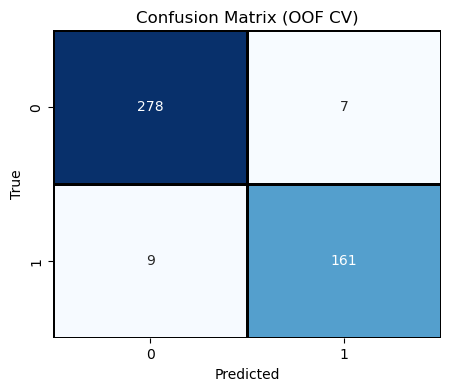

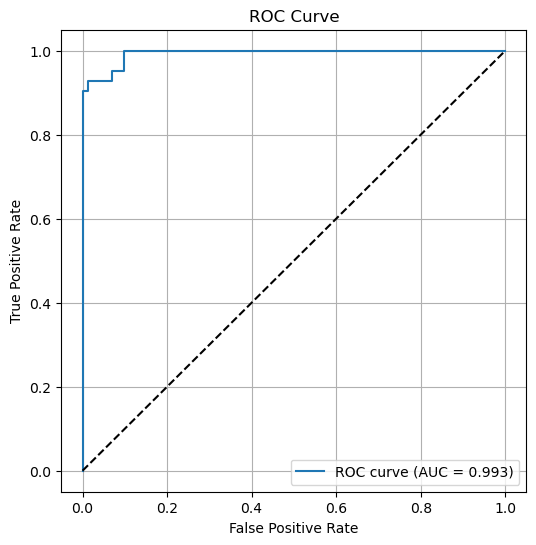

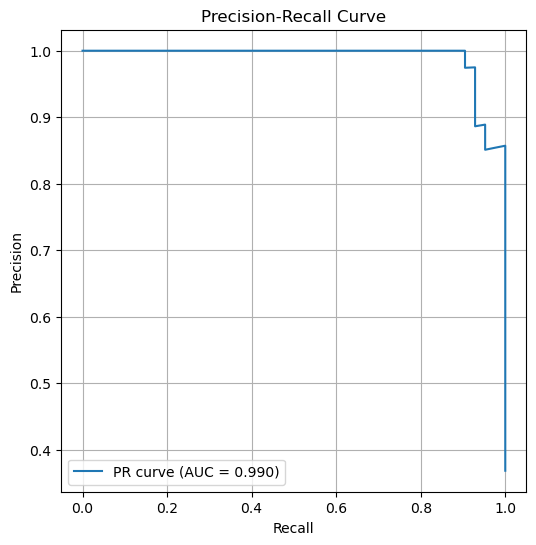

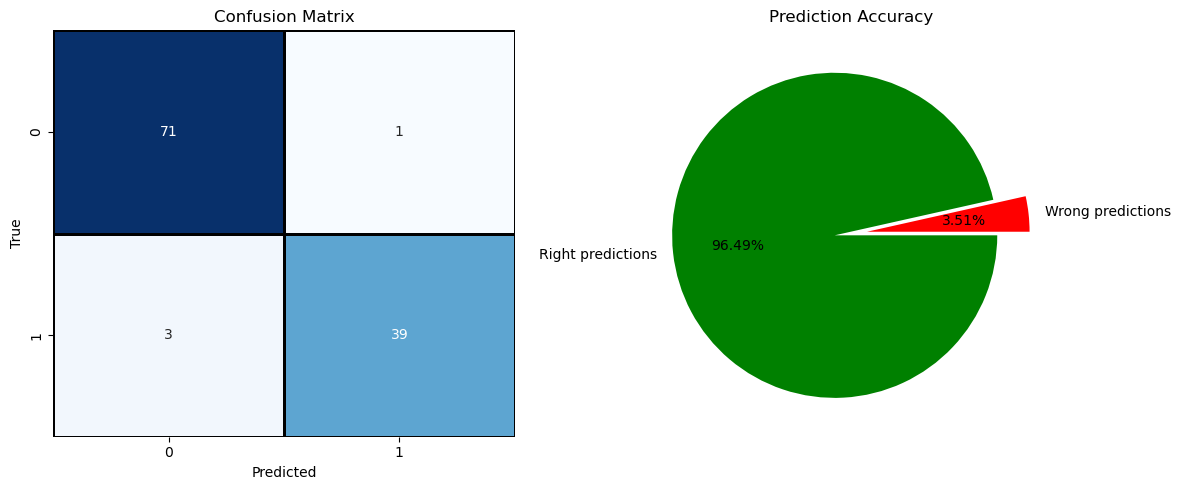

In [66]:
pipe = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid= {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [5, 10, 20],
    'clf__min_samples_split': [5, 10],
    'clf__min_samples_leaf': [2, 4],
    'clf__class_weight': [None, 'balanced']
}

f2_scorer = make_scorer(fbeta_score, beta=2)
scorer = {'name':'accuracy', 'metrics':'accuracy'}

best_model_rf, df_final, cm, best_threshold_rf = best_parametrs_and_metrics(pipe, param_grid, scorer, X_train, y_train, X_test, y_test)
get_oof_matrix(best_model_rf, X_train, y_train)
get_final_visual(best_model_rf, X_test, y_test, cm)

best_thresholds['RandomForest'] = best_threshold_rf

# XGBoost

Лучшие параметры: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__scale_pos_weight': 1.6764705882352942, 'clf__subsample': 0.7}
Лучший f2-score по кросс-валидации: 0.964
Лучший порог по f2: 0.441, f2 = 0.981 (на тесте)
      accuracy  precision   recall        f1        f2   roc_auc    pr_auc
Test  0.991228        1.0  0.97619  0.987952  0.980861  0.993717  0.992584


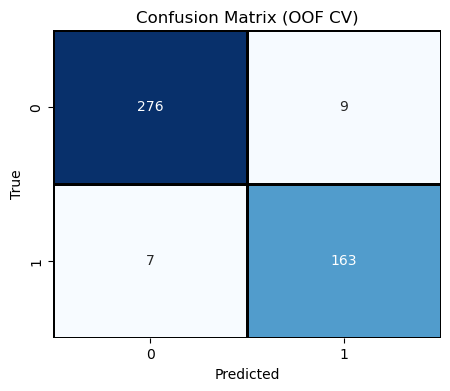

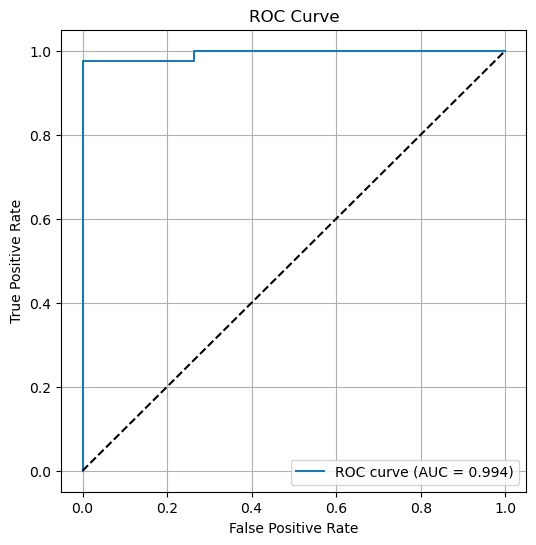

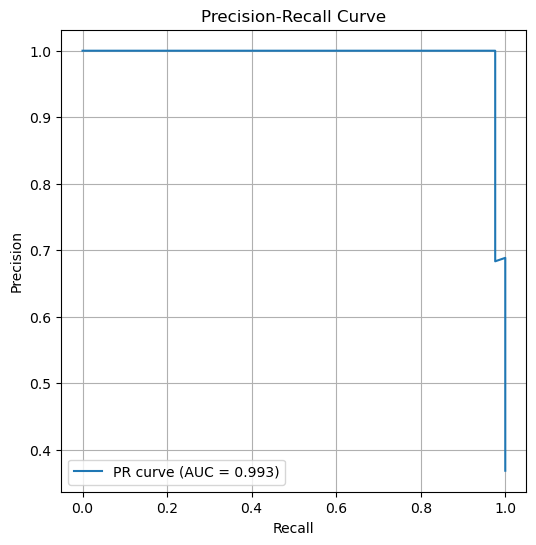

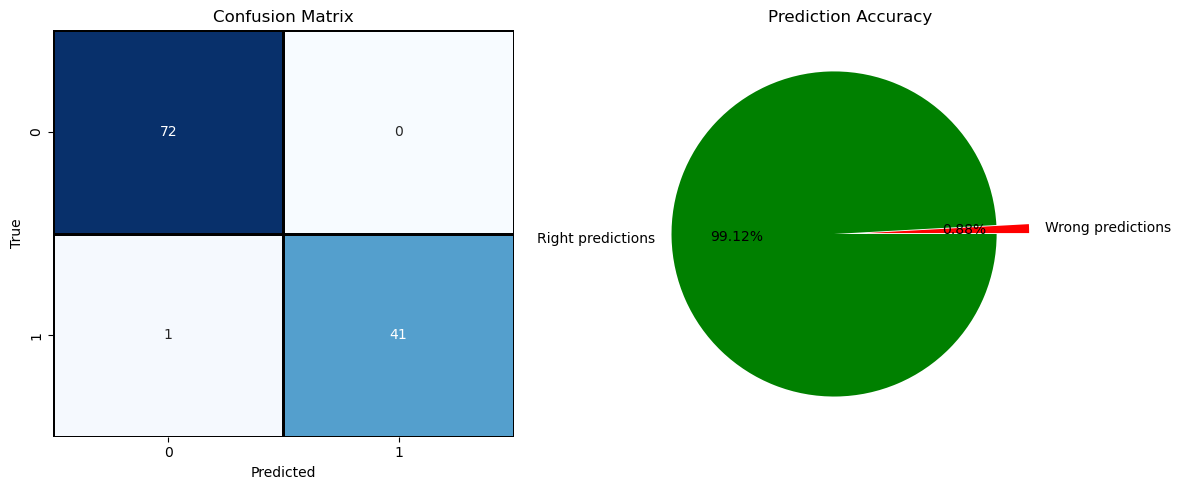

In [68]:
pipe= Pipeline([
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

param_grid= {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.1, 0.2],
    'clf__subsample': [0.7, 1.0],
    'clf__colsample_bytree': [0.7, 1.0],
    'clf__scale_pos_weight': [1, sum(y_train==0)/sum(y_train==1)]
}

f2_scorer = make_scorer(fbeta_score, beta=2)
scorer = {'name':'f2', 'metrics':f2_scorer}

best_model_xgb, df_final, cm, best_threshold_xgb = best_parametrs_and_metrics(pipe, param_grid, scorer, X_train, y_train, X_test, y_test)
get_oof_matrix(best_model_xgb, X_train, y_train)
get_final_visual(best_model_xgb, X_test, y_test, cm)

best_thresholds['XGBoost'] = best_threshold_xgb

# Проверка ансамбля с гиперпараметрами/ по умолчанию

In [76]:
SGK = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
soft_models = [
    ('LogReg', best_model_log ),
    ('RandomForest', best_model_rf),
    ('XGBoost',best_model_xgb),
    ('SVM_Linear', best_model_svc),
]


metrics = ['Recall', 'Precision', 'F1-Score', 'Accuracy', 'ROC AUC']

for fold, (train_index, validation_index) in enumerate(SGK.split(X_train_t, y_train_t), start=1):
    fold_probs = []

    for name, model in soft_models:
        if name in ['LogReg', 'SVM_Linear']:
            X_data, y_data = X_train_scaled_l_c, y_train_l_c
        else:
            X_data, y_data = X_train_t, y_train_t

        X_data = np.array(X_data)
        y_data = np.array(y_data)

        X_train_tmp, y_train_tmp = X_data[train_index], y_data[train_index]
        X_validation_tmp, y_validation_tmp = X_data[validation_index], y_data[validation_index]

        model_tmp = clone(model)
        
        model_tmp.fit(X_train_tmp, y_train_tmp)
        proba = model_tmp.predict_proba(X_validation_tmp)[:, 1]
        fold_probs.append(proba)

    soft_avg_proba = np.mean(np.vstack(fold_probs), axis=0)
    soft_final = (soft_avg_proba >= 0.5).astype(int)

    results.append({
        'Type': 'Soft Voting New',
        'Fold': fold,
        'Accuracy': accuracy_score(y_validation_tmp, soft_final),
        'Precision': precision_score(y_validation_tmp, soft_final, pos_label=1),
        'Recall': recall_score(y_validation_tmp, soft_final, pos_label=1),
        'F1-Score': f1_score(y_validation_tmp, soft_final, pos_label=1),
        'ROC AUC': roc_auc_score(y_validation_tmp, soft_avg_proba)
    })



voting_summary = pd.DataFrame(results)
voting_performance = voting_summary.groupby('Type')[metrics].agg(['mean','std']).reset_index()
voting_performance


Type    Recall           Precision            F1-Score  \
                        mean       std      mean       std      mean   
0      Hard Voting  0.941176  0.073366  0.994444  0.017568  0.965477   
1      Soft Voting  0.952941  0.066782  0.982639  0.028018  0.966237   
2  Soft Voting New  0.947059  0.013153  0.970410  0.029414  0.958470   

             Accuracy             ROC AUC            
        std      mean       std      mean       std  
0  0.038545  0.975797  0.026361       NaN       NaN  
1  0.037546  0.975749  0.026357  0.994183  0.010502  
2  0.018990  0.969231  0.014328  0.993086  0.005320

Стандартное отклонение сильно уменьшилось, модели стали стабильнее по фолдам.

- Precision немного упала чуть увеличился разброс, Recall увеличился разброс уменьшился значительно.
- F1, Accuracy - изменилось незначительно, немного снизился разброс
- ROC AUC немного уменьшилось, но всё ещё очень высокое.

Модель стабильнее (меньше разброс по фолдам).
Стабильность важнее минимального прироста метрик.

# Финальная проверка на тесте ансамбля

                      Recall  Precision  F1-Score  Accuracy   ROC AUC
Soft Voting на test  0.97619        1.0  0.987952  0.991228  0.996032


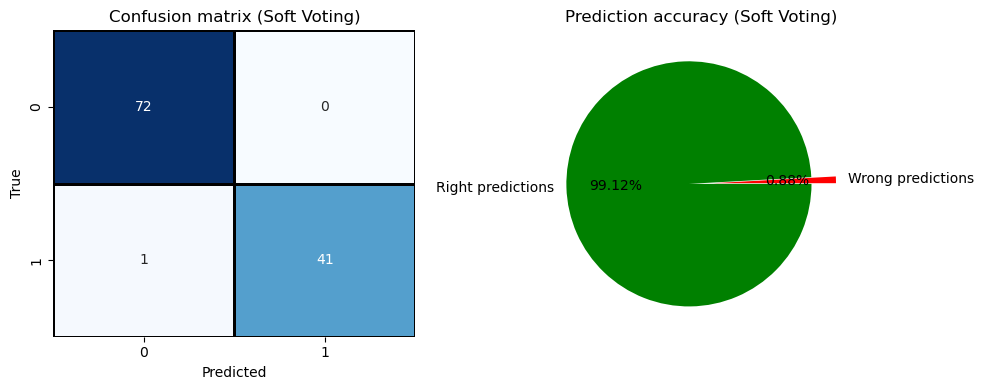

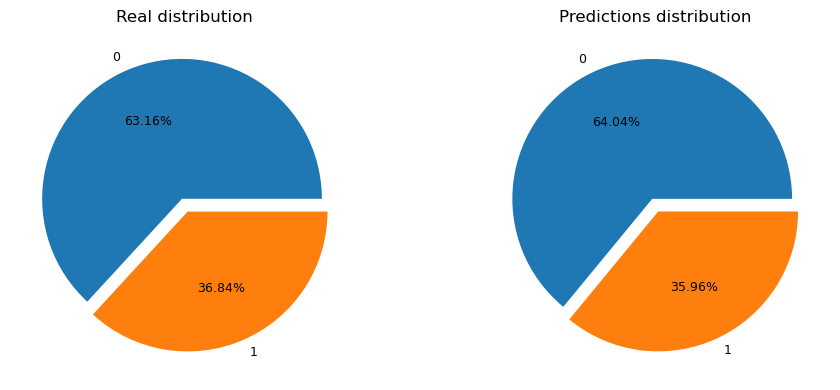

In [78]:
soft_models = [
    ('LogReg', best_model_log),
    ('RandomForest', best_model_rf),
    ('XGBoost', best_model_xgb),
    ('SVM_Linear', best_model_svc),
]

probas = []
probas_adjusted = []
for name, model in soft_models:
    if name in ['LogReg', 'SVM_Linear']:
        X_tr, X_te = X_train_scaled_l_c, X_test_scaled_l_c
        y_tr = y_train_l_c
    else:
        X_tr, X_te = X_train_t, X_test_t
        y_tr = y_train_t
    
    model_tmp = clone(model)
    model_tmp.fit(X_tr, y_tr)
    
    p = model_tmp.predict_proba(X_te)[:, 1]
    probas.append(p)

soft_proba = np.mean(np.vstack(probas), axis=0)
soft_pred = (soft_proba >= 0.5).astype(int)


metrics_ = {
    "Recall": recall_score(y_test_l_c, soft_pred),
    "Precision": precision_score(y_test_l_c, soft_pred),
    "F1-Score": f1_score(y_test_l_c, soft_pred),
    "Accuracy": accuracy_score(y_test_l_c, soft_pred),
    "ROC AUC": roc_auc_score(y_test_l_c, soft_proba),
}

df_metrics = pd.DataFrame([metrics_], index=['Soft Voting на test'])
print(df_metrics)


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))


cm = confusion_matrix(y_test_l_c, soft_pred)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues', linewidths=2, linecolor='k', ax=ax1)
ax1.set_title("Confusion matrix (Soft Voting)")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")


df_cm = pd.DataFrame({
    "Predictions": [cm[0][1] + cm[1][0], cm[0][0] + cm[1][1]]
}, index=["Wrong predictions", "Right predictions"])

df_cm.plot.pie(
    y='Predictions',
    ax=ax2,
    legend=False,
    explode=[0.1, 0.1],
    autopct='%1.2f%%',
    textprops={'fontsize': 10},
    colors=["red", "green"]
)
ax2.set_ylabel("")
ax2.set_title("Prediction accuracy (Soft Voting)")

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10, 4))

pd.Series(y_test_l_c).value_counts().sort_index().plot.pie(
    explode=[0.05, 0.05],
    autopct='%1.2f%%',
    textprops={'fontsize': 9},
    ax=ax1,
    title='Real distribution',
    ylabel=''
)

pd.Series(soft_pred).value_counts().sort_index().plot.pie(
    explode=[0.05, 0.05],
    autopct='%1.2f%%',
    textprops={'fontsize': 9},
    ax=ax2,
    title='Predictions distribution',
    ylabel=''
)

plt.tight_layout()
plt.show()
